In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\CodeAlpha_CarPricePrediction\dataset\car data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(2)

In [11]:
df[df.duplicated()]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(299, 9)

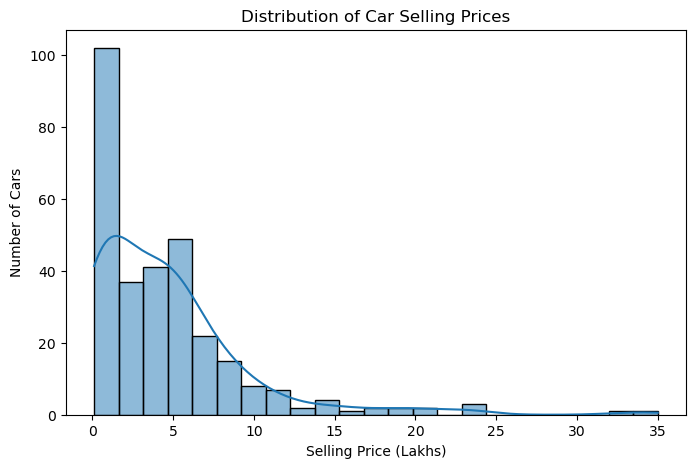

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")

plt.show()

## EDA insights
Insight: The distribution of selling prices is positively skewed, with most vehicles concentrated in the lower price range and a small number of high-priced vehicles extending the distribution toward approximately ₹35 lakh. The mean selling price is higher than the median, which is consistent with the right-skewed distribution.

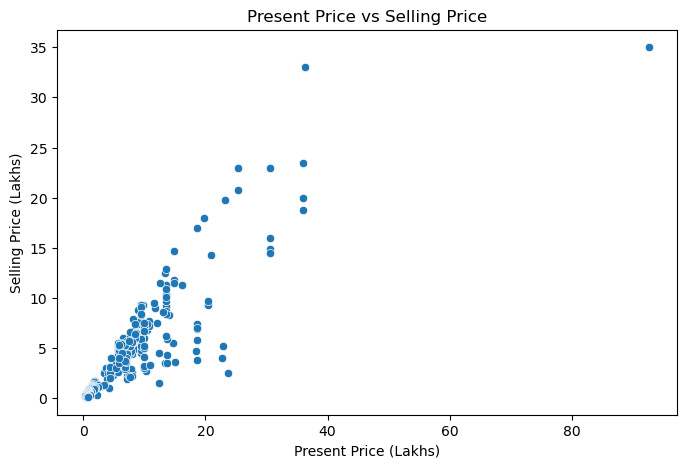

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

## Insight: 
The scatter plot shows a strong positive relationship between present price and selling price. In general, vehicles with higher present prices tend to have higher selling prices. However, the relationship is not perfectly linear, indicating that other factors such as vehicle age, mileage, fuel type, and transmission may also influence resale prices. A few high-value observations appear as potential outliers and will be investigated during further analysis.

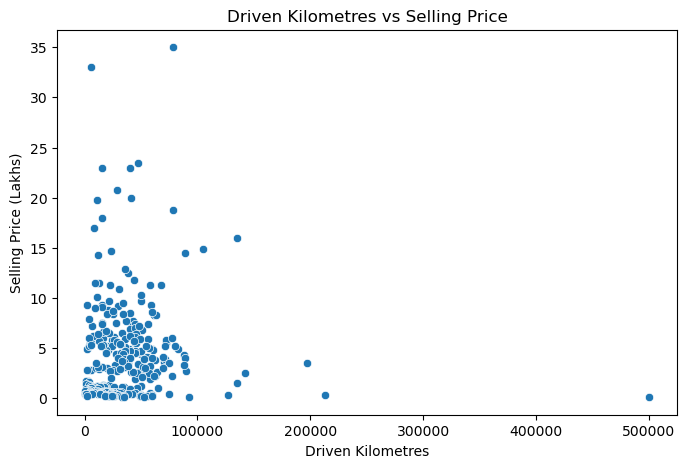

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Driven_kms",
    y="Selling_Price"
)

plt.title("Driven Kilometres vs Selling Price")
plt.xlabel("Driven Kilometres")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

## Insight: 
The scatter plot indicates a negative relationship between driven kilometres and selling price. Cars with lower mileage generally have higher resale prices, while highly driven vehicles tend to have lower selling prices. However, the relationship is not very strong, suggesting that other factors also contribute significantly to the selling price. A few extreme mileage observations require further investigation.

In [18]:
df["Year"].value_counts().sort_index()

Year
2003     2
2004     1
2005     4
2006     4
2007     2
2008     7
2009     6
2010    15
2011    19
2012    23
2013    33
2014    38
2015    60
2016    49
2017    35
2018     1
Name: count, dtype: int64

In [19]:
reference_year = df["Year"].max()

df["Car_Age"] = reference_year - df["Year"]

In [20]:
df[["Year", "Car_Age"]].head(10)

,Year,Car_Age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4
5,2018,0
6,2015,3
7,2015,3
8,2016,2
9,2015,3


In [21]:
df["Car_Age"].describe()

count    299.000000
mean       4.384615
std        2.896868
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       15.000000
Name: Car_Age, dtype: float64

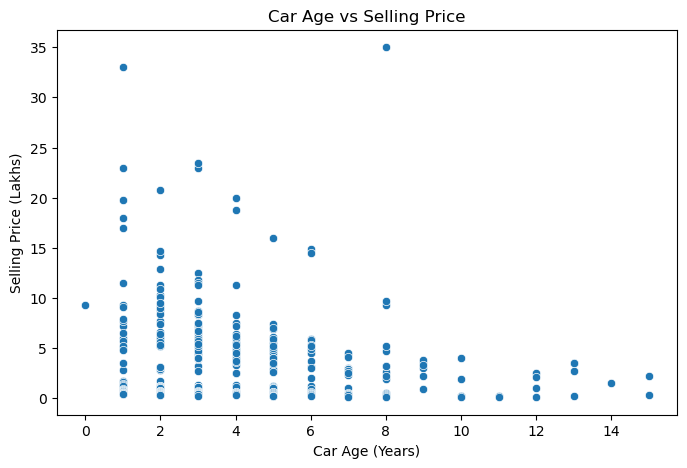

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

In [23]:
df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

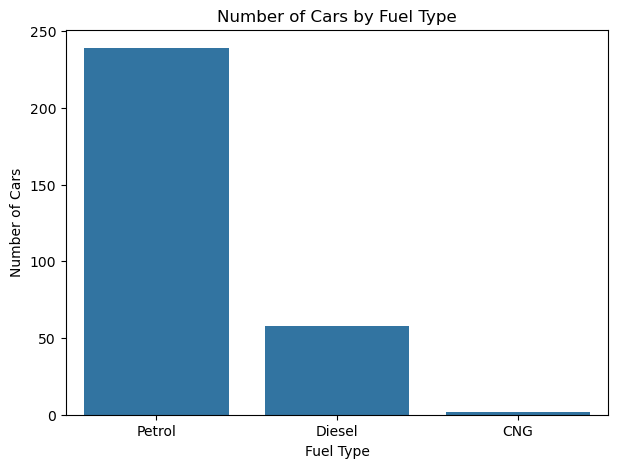

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Fuel_Type")

plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.show()

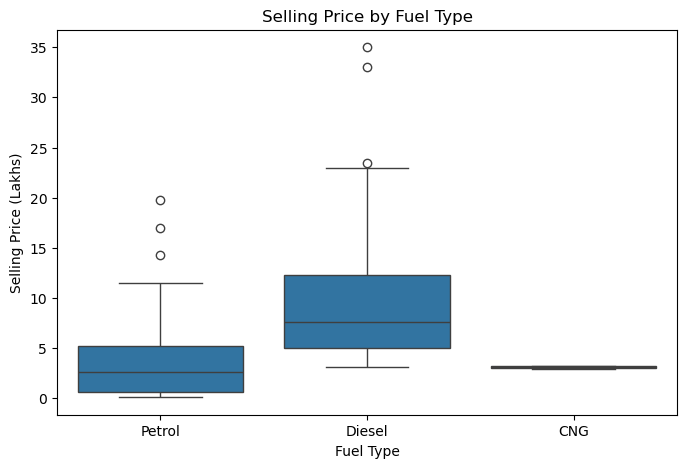

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

In [26]:
df.groupby("Fuel_Type")["Selling_Price"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Fuel_Type,,,,,
CNG,2,3.100000,3.10,2.95,3.25
Diesel,58,10.102759,7.60,3.10,35.00
Petrol,239,3.264184,2.65,0.10,19.75


## Insight: 
Petrol vehicles dominate the dataset, accounting for approximately 80% of observations, while Diesel vehicles account for about 19%. Only two CNG vehicles are present, so conclusions about CNG vehicles are limited. Diesel vehicles have the highest mean and median selling prices in the dataset, while Petrol vehicles have substantially lower values. However, this relationship may also be influenced by other vehicle characteristics such as present price, age and car model.

In [27]:
df["Selling_type"].value_counts()

Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

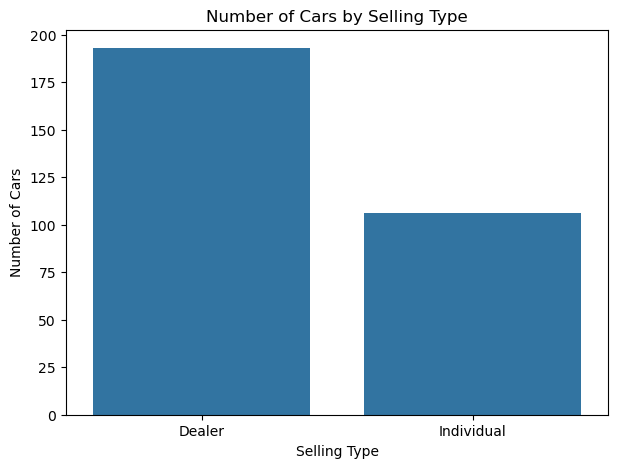

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Selling_type")

plt.title("Number of Cars by Selling Type")
plt.xlabel("Selling Type")
plt.ylabel("Number of Cars")

plt.show()

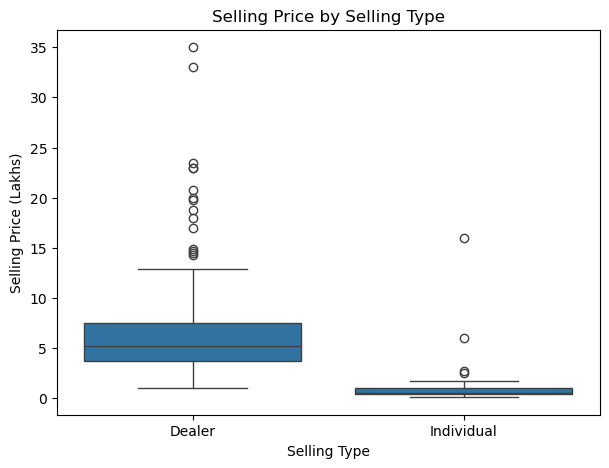

In [29]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Selling_type",
    y="Selling_Price"
)

plt.title("Selling Price by Selling Type")
plt.xlabel("Selling Type")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

In [30]:
df.groupby("Selling_type")["Selling_Price"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Selling_type,,,,,
Dealer,193,6.632021,5.250,1.05,35.0
Individual,106,0.870943,0.515,0.10,16.0


## Insight: 
Dealers account for approximately 64.5% of the vehicles, while individual sellers account for 35.5%. Dealer-sold vehicles have substantially higher mean and median selling prices than individually sold vehicles. However, this association does not imply that selling through a dealer directly causes a higher selling price, as other factors such as vehicle model, age and present price may contribute to the observed difference.

In [31]:
df["Transmission"].value_counts()

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

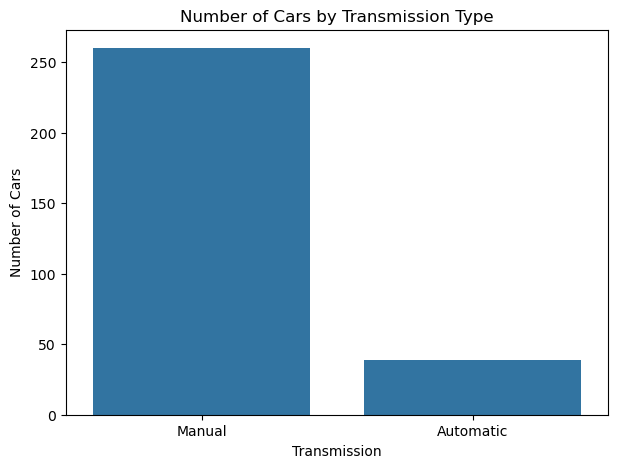

In [32]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Transmission")

plt.title("Number of Cars by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")

plt.show()

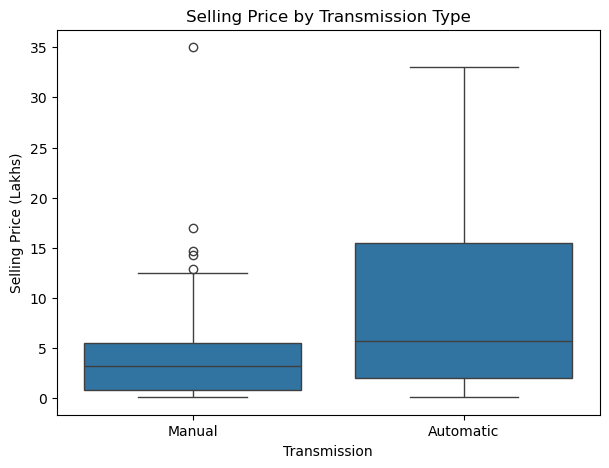

In [33]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Transmission",
    y="Selling_Price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

In [34]:
df.groupby("Transmission")["Selling_Price"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Transmission,,,,,
Automatic,39,9.071795,5.75,0.17,33.0
Manual,260,3.917308,3.25,0.10,35.0


## Insight: 
Manual vehicles dominate the dataset, accounting for approximately 87% of observations, while automatic vehicles account for approximately 13%. Automatic vehicles have higher mean and median selling prices than manual vehicles. This indicates an association between transmission type and selling price, although the difference may also reflect other vehicle characteristics such as present price, age and car model.

In [35]:
df["Owner"].value_counts().sort_index()

Owner
0    288
1     10
3      1
Name: count, dtype: int64

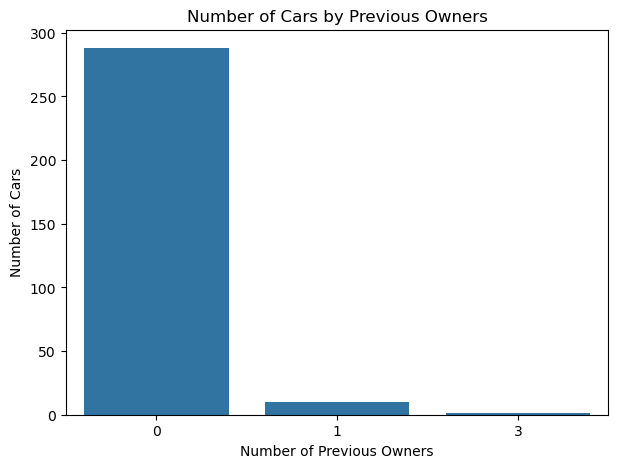

In [36]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Owner"
)

plt.title("Number of Cars by Previous Owners")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Number of Cars")

plt.show()

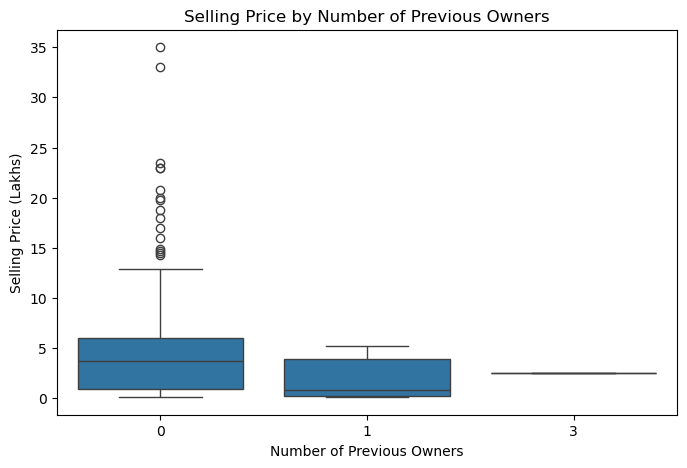

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Owner",
    y="Selling_Price"
)

plt.title("Selling Price by Number of Previous Owners")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Selling Price (Lakhs)")

plt.show()

In [38]:
df.groupby("Owner")["Selling_Price"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Owner,,,,,
0,288,4.687847,3.7,0.10,35.00
1,10,1.970000,0.8,0.15,5.25
3,1,2.500000,2.5,2.50,2.50


## Insight: 
The dataset is highly imbalanced with respect to previous ownership, with approximately 96.3% of vehicles recorded with zero previous owners. Vehicles with zero previous owners have a higher median and mean selling price than vehicles with one previous owner. However, the one-owner and three-owner groups contain very few observations, particularly the three-owner group with only one vehicle, so strong conclusions about the effect of previous ownership on selling price cannot be drawn from this dataset alone.

In [39]:
numeric_cols = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Driven_kms",
    "Owner",
    "Car_Age"
]

In [40]:
corr_matrix = df[numeric_cols].corr()

corr_matrix

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age
Year,1.000000,0.234369,-0.053167,-0.525714,-0.181639,-1.000000
Selling_Price,0.234369,1.000000,0.876305,0.028566,-0.087880,-0.234369
Present_Price,-0.053167,0.876305,1.000000,0.205224,0.009948,0.053167
Driven_kms,-0.525714,0.028566,0.205224,1.000000,0.089367,0.525714
Owner,-0.181639,-0.087880,0.009948,0.089367,1.000000,0.181639
Car_Age,-1.000000,-0.234369,0.053167,0.525714,0.181639,1.000000


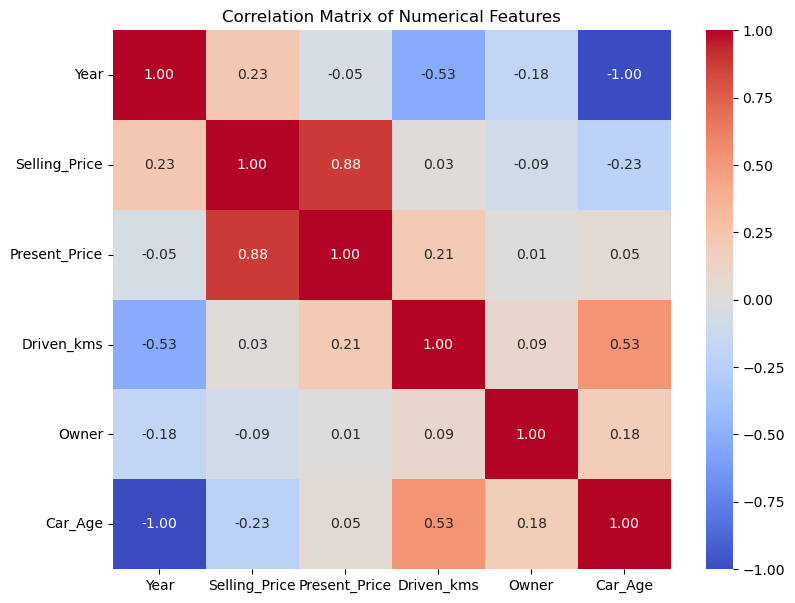

In [41]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

## Insight: 
The correlation analysis shows that Present_Price has the strongest positive relationship with Selling_Price (r = 0.876), indicating that it is likely to be an important predictor. Car_Age has a weak negative relationship with selling price (r = -0.234), while Year has a weak positive relationship (r = 0.234). Driven_kms and Owner show very weak linear relationships with selling price. Year and Car_Age have a perfect negative correlation because Car_Age was derived directly from Year, so both variables should not be used simultaneously in the final model.

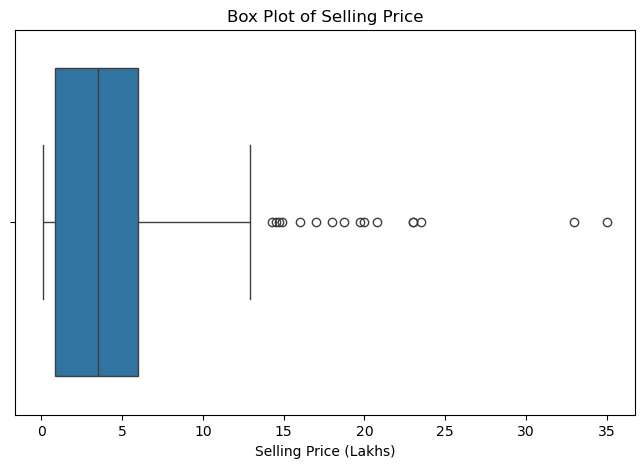

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Selling_Price"])

plt.title("Box Plot of Selling Price")
plt.xlabel("Selling Price (Lakhs)")

plt.show()

In [43]:
Q1 = df["Selling_Price"].quantile(0.25)
Q3 = df["Selling_Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 0.8500000000000001
Q3: 6.0
IQR: 5.15
Lower Bound: -6.875
Upper Bound: 13.725000000000001


In [44]:
outliers = df[
    (df["Selling_Price"] < lower_bound) |
    (df["Selling_Price"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 16


In [45]:
outliers[
    [
        "Car_Name",
        "Year",
        "Selling_Price",
        "Present_Price",
        "Driven_kms",
        "Fuel_Type",
        "Selling_type",
        "Transmission",
        "Owner"
    ]
].sort_values("Selling_Price", ascending=False)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
86,land cruiser,2010,35.00,92.60,78000,Diesel,Dealer,Manual,0
64,fortuner,2017,33.00,36.23,6000,Diesel,Dealer,Automatic,0
63,fortuner,2015,23.50,35.96,47000,Diesel,Dealer,Automatic,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
82,innova,2017,23.00,25.39,15000,Diesel,Dealer,Automatic,0
96,innova,2016,20.75,25.39,29000,Diesel,Dealer,Automatic,0
59,fortuner,2014,19.99,35.96,41000,Diesel,Dealer,Automatic,0
66,innova,2017,19.75,23.15,11000,Petrol,Dealer,Automatic,0
62,fortuner,2014,18.75,35.96,78000,Diesel,Dealer,Automatic,0
52,innova,2017,18.00,19.77,15000,Diesel,Dealer,Automatic,0


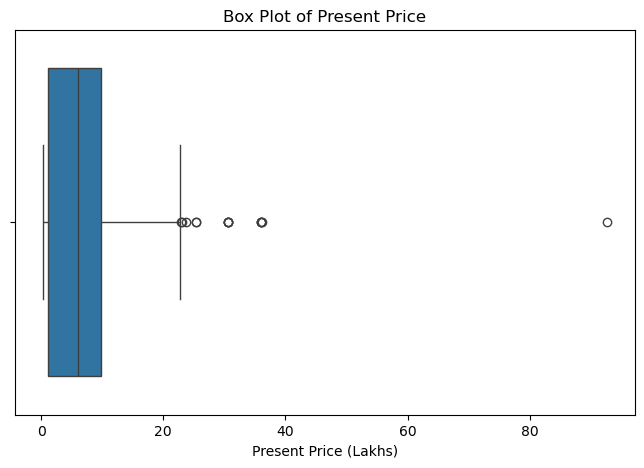

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Present_Price"])

plt.title("Box Plot of Present Price")
plt.xlabel("Present Price (Lakhs)")

plt.show()

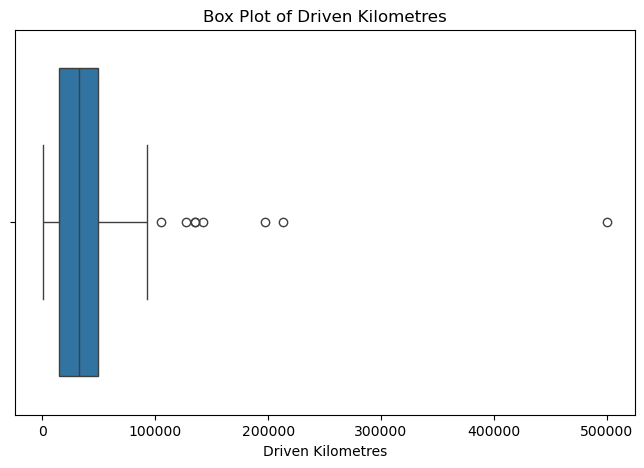

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Driven_kms"])

plt.title("Box Plot of Driven Kilometres")
plt.xlabel("Driven Kilometres")

plt.show()

In [57]:
outliers_selling = df[
    (df["Selling_Price"] < lower_bound) |
    (df["Selling_Price"] > upper_bound)
]

print("Number of Selling Price outliers:", len(outliers_selling))

Number of Selling Price outliers: 16


In [59]:
display(outliers_selling)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
50,fortuner,2012,14.90,30.61,104707,Diesel,Dealer,Automatic,0,6
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0,3
52,innova,2017,18.00,19.77,15000,Diesel,Dealer,Automatic,0,1
53,fortuner,2013,16.00,30.61,135000,Diesel,Individual,Automatic,0,5
59,fortuner,2014,19.99,35.96,41000,Diesel,Dealer,Automatic,0,4
62,fortuner,2014,18.75,35.96,78000,Diesel,Dealer,Automatic,0,4
63,fortuner,2015,23.50,35.96,47000,Diesel,Dealer,Automatic,0,3
64,fortuner,2017,33.00,36.23,6000,Diesel,Dealer,Automatic,0,1
66,innova,2017,19.75,23.15,11000,Petrol,Dealer,Automatic,0,1
69,corolla altis,2016,14.25,20.91,12000,Petrol,Dealer,Manual,0,2


In [60]:
Q1_present = df["Present_Price"].quantile(0.25)
Q3_present = df["Present_Price"].quantile(0.75)

print("Q1:", Q1_present)
print("Q3:", Q3_present)

Q1: 1.2
Q3: 9.84


In [61]:
IQR_present = Q3_present - Q1_present

print("IQR:", IQR_present)

IQR: 8.64


In [62]:
lower_present = Q1_present - 1.5 * IQR_present
upper_present = Q3_present + 1.5 * IQR_present

print("Lower Bound:", lower_present)
print("Upper Bound:", upper_present)

Lower Bound: -11.760000000000002
Upper Bound: 22.8


In [63]:
outliers_present = df[
    (df["Present_Price"] < lower_present) |
    (df["Present_Price"] > upper_present)
]

print("Number of Present Price outliers:", len(outliers_present))

Number of Present Price outliers: 14


In [64]:
display(
    outliers_present[
        ["Car_Name", "Year", "Present_Price", "Driven_kms", "Selling_Price"]
    ]
)

,Car_Name,Year,Present_Price,Driven_kms,Selling_Price
50,fortuner,2012,30.61,104707,14.90
51,fortuner,2015,30.61,40000,23.00
53,fortuner,2013,30.61,135000,16.00
59,fortuner,2014,35.96,41000,19.99
62,fortuner,2014,35.96,78000,18.75
63,fortuner,2015,35.96,47000,23.50
64,fortuner,2017,36.23,6000,33.00
66,innova,2017,23.15,11000,19.75
78,corolla altis,2010,22.83,80000,5.25
79,fortuner,2012,30.61,89000,14.50


In [65]:
Q1_kms = df["Driven_kms"].quantile(0.25)
Q3_kms = df["Driven_kms"].quantile(0.75)

print("Q1:", Q1_kms)
print("Q3:", Q3_kms)

Q1: 15000.0
Q3: 48883.5


In [66]:
IQR_kms = Q3_kms - Q1_kms

print("IQR:", IQR_kms)

IQR: 33883.5


In [67]:
lower_kms = Q1_kms - 1.5 * IQR_kms
upper_kms = Q3_kms + 1.5 * IQR_kms

print("Lower Bound:", lower_kms)
print("Upper Bound:", upper_kms)

Lower Bound: -35825.25
Upper Bound: 99708.75


In [68]:
outliers_kms = df[
    (df["Driven_kms"] < lower_kms) |
    (df["Driven_kms"] > upper_kms)
]

print("Number of Driven Kms outliers:", len(outliers_kms))

Number of Driven Kms outliers: 8


In [69]:
display(
    outliers_kms[
        ["Car_Name", "Year", "Present_Price", "Driven_kms", "Selling_Price"]
    ]
)

,Car_Name,Year,Present_Price,Driven_kms,Selling_Price
37,800,2003,2.28,127000,0.35
50,fortuner,2012,30.61,104707,14.90
53,fortuner,2013,30.61,135000,16.00
77,corolla,2004,12.35,135154,1.50
84,innova,2005,13.46,197176,3.49
85,camry,2006,23.73,142000,2.50
179,Honda Karizma,2010,1.05,213000,0.31
196,Activa 3g,2008,0.52,500000,0.17


## Insight:
Selling Price — 16 outliers

The Selling Price outliers represent vehicles with unusually high or low resale prices compared with the majority of cars. These values can occur because of differences in vehicle type, age, brand, and market value.

Present Price — 14 outliers

The Present Price outliers mainly represent high-value vehicles. Since expensive cars naturally have higher present prices, these observations should not automatically be treated as errors.

Driven Kms — 8 outliers

The 8 Driven Kms outliers represent vehicles with unusually high mileage. For example, some vehicles have driven over 100,000 km, with one reaching 500,000 km. These can be genuine observations rather than data errors.

Overall conclusion

The detected outliers appear to be legitimate vehicle observations rather than obvious data-entry errors. Therefore, we will retain them instead of removing them.

In [70]:
df["Car_Age"] = 2026 - df["Year"]

In [71]:
print(df[["Year", "Car_Age"]].head())

   Year  Car_Age
0  2014       12
1  2013       13
2  2017        9
3  2011       15
4  2014       12


In [72]:
print(df["Car_Age"].describe())

count    299.000000
mean      12.384615
std        2.896868
min        8.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       23.000000
Name: Car_Age, dtype: float64


In [73]:
print("Minimum Car Age:", df["Car_Age"].min())
print("Maximum Car Age:", df["Car_Age"].max())

Minimum Car Age: 8
Maximum Car Age: 23


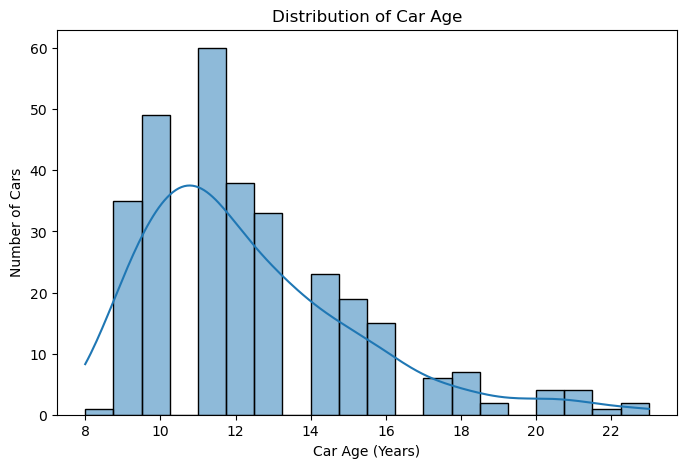

In [74]:
plt.figure(figsize=(8,5))
sns.histplot(df["Car_Age"], bins=20, kde=True)
plt.title("Distribution of Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Number of Cars")
plt.show()

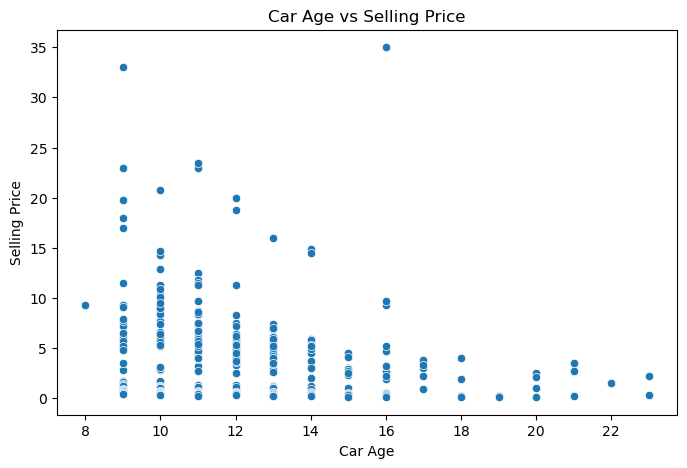

In [75]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Car_Age", y="Selling_Price")
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

## Insight
The Car_Age feature makes the effect of vehicle age easier for the model to learn.
The scatter plot allows us to examine how selling price changes as vehicles become older.
We should expect a general negative relationship: older vehicles tend to have lower resale prices.
However, the relationship isn't perfectly linear because brand, present price, mileage, fuel type, and transmission also affect selling price.

In [76]:
df["Kms_Per_Year"] = df["Driven_kms"] / df["Car_Age"].replace(0, 1)

In [77]:
print(df[["Driven_kms", "Car_Age", "Kms_Per_Year"]].head())

   Driven_kms  Car_Age  Kms_Per_Year
0       27000       12   2250.000000
1       43000       13   3307.692308
2        6900        9    766.666667
3        5200       15    346.666667
4       42450       12   3537.500000


In [78]:
df["Price_Depreciation"] = df["Present_Price"] - df["Selling_Price"]

In [79]:
print(df[["Present_Price", "Selling_Price", "Price_Depreciation"]].head())

   Present_Price  Selling_Price  Price_Depreciation
0           5.59           3.35                2.24
1           9.54           4.75                4.79
2           9.85           7.25                2.60
3           4.15           2.85                1.30
4           6.87           4.60                2.27


In [80]:
print(df[["Car_Age", "Kms_Per_Year", "Price_Depreciation"]].describe())

          Car_Age  Kms_Per_Year  Price_Depreciation
count  299.000000    299.000000          299.000000
mean    12.384615   2785.223440            2.951405
std      2.896868   2288.319488            4.836742
min      8.000000     50.000000            0.030000
25%     10.000000   1375.000000            0.390000
50%     12.000000   2538.461538            1.640000
75%     14.000000   3679.561688            3.350000
max     23.000000  27777.777778           57.600000


In [81]:
print("Negative Kms_Per_Year:", (df["Kms_Per_Year"] < 0).sum())
print("Negative Price_Depreciation:", (df["Price_Depreciation"] < 0).sum())

Negative Kms_Per_Year: 0
Negative Price_Depreciation: 0


## Insights
Car_Age: ranges from 8 to 23 years, with an average of 12.38 years.
Kms_Per_Year: average usage is about 2,785 km/year. The maximum of 27,777.78 km/year indicates some heavily used vehicles.
Price_Depreciation: average difference between present price and selling price is 2.95, with a maximum of 57.60.
No negative Kms_Per_Year or Price_Depreciation values were found, so the engineered features are valid.

In [82]:
correlation = df[
    ["Selling_Price", "Present_Price", "Driven_kms",
     "Car_Age", "Kms_Per_Year"]
].corr()["Selling_Price"].sort_values(ascending=False)

print(correlation)

Selling_Price    1.000000
Present_Price    0.876305
Kms_Per_Year     0.122906
Driven_kms       0.028566
Car_Age         -0.234369
Name: Selling_Price, dtype: float64


In [87]:
X = df.drop(columns=["Selling_Price", "Price_Depreciation"])
y = df["Selling_Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (299, 10)
y shape: (299,)


In [88]:
print("Features:")
print(X.columns.tolist())

Features:
['Car_Name', 'Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age', 'Kms_Per_Year']


In [89]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Kms_Per_Year']
Categorical features: ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (239, 10)
X_test shape: (60, 10)
y_train shape: (239,)
y_test shape: (60,)


In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [92]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (239, 98)
Processed X_test shape: (60, 98)


In [93]:
print("Training data type:", type(X_train_processed))
print("Testing data type:", type(X_test_processed))

Training data type: <class 'scipy.sparse._csr.csr_matrix'>
Testing data type: <class 'scipy.sparse._csr.csr_matrix'>


In [94]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_processed, y_train)

y_pred_lr = lr_model.predict(X_test_processed)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 1.4625489393743625
MSE : 6.894171175890906
RMSE: 2.6256753751922393
R²  : 0.7325068469622517


In [96]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train_processed, y_train)

y_pred_dt = dt_model.predict(X_test_processed)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [97]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Results
--------------------
MAE : 1.4419438604143064
MSE : 9.670833628565298
RMSE: 3.109796396641635
R²  : 0.6247726211303235


In [98]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [99]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
--------------------
MAE : 1.4658205729623726
MSE : 12.871476545073502
RMSE: 3.5876840085316184
R²  : 0.5005879956486278


In [100]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],
    "R2": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

print(model_results)

               Model       MAE      RMSE        R2
0  Linear Regression  1.462549  2.625675  0.732507
1      Decision Tree  1.441944  3.109796  0.624773
2      Random Forest  1.465821  3.587684  0.500588


In [101]:
best_model = model_results.loc[
    model_results["R2"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model    Linear Regression
MAE               1.462549
RMSE              2.625675
R2                0.732507
Name: 0, dtype: object


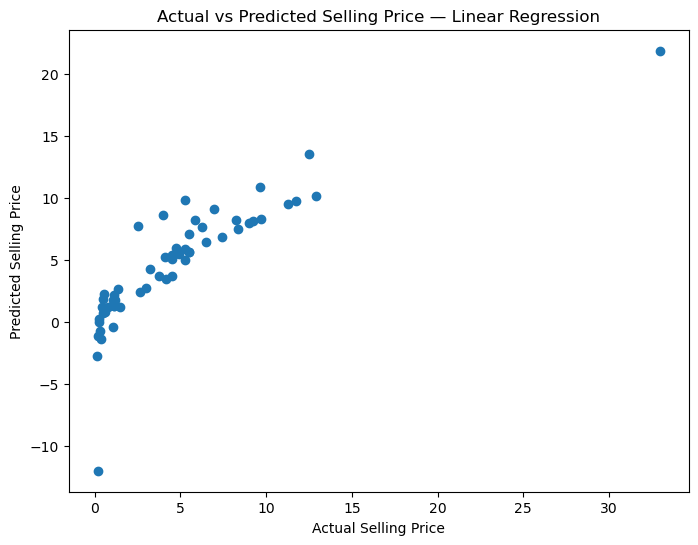

In [102]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price — Linear Regression")

plt.show()

In [103]:
print("FINAL MODEL — LINEAR REGRESSION")
print("--------------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

FINAL MODEL — LINEAR REGRESSION
--------------------------------
MAE : 1.4625489393743625
RMSE: 2.6256753751922393
R²  : 0.7325068469622517


In [104]:
comparison = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": y_pred_lr
})

comparison["Error"] = (
    comparison["Actual_Price"] -
    comparison["Predicted_Price"]
)

display(comparison.head(10))

,Actual_Price,Predicted_Price,Error
0,8.99,7.932341,1.057659
1,8.35,7.499036,0.850964
2,0.45,1.187453,-0.737453
3,7.45,6.809549,0.640451
4,5.25,9.790350,-4.540350
5,5.25,4.943557,0.306443
6,5.85,8.173145,-2.323145
7,1.15,2.180612,-1.030612
8,9.25,8.128215,1.121785
9,0.38,-1.375808,1.755808


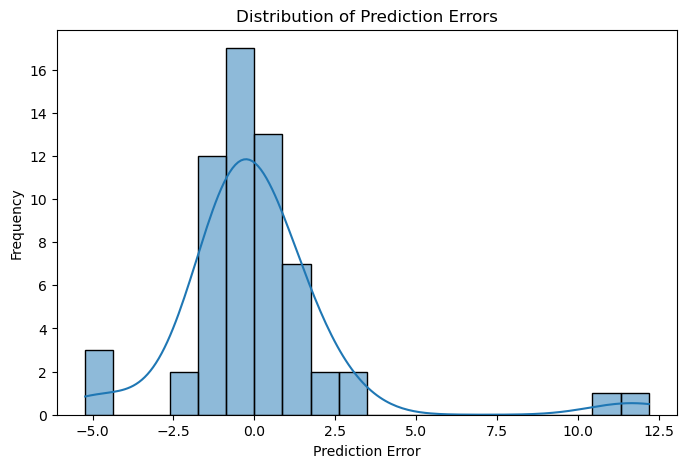

In [105]:
errors = y_test.values - y_pred_lr

plt.figure(figsize=(8, 5))

sns.histplot(errors, bins=20, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

In [106]:
feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coefficients.head(15))

,Feature,Coefficient,Absolute_Coefficient
75,cat__Car_Name_innova,5.065662,5.065662
77,cat__Car_Name_land cruiser,-2.421650,2.421650
27,cat__Car_Name_Honda Activa 4G,-1.936576,1.936576
70,cat__Car_Name_fortuner,1.926723,1.926723
0,cat__Car_Name_800,1.916999,1.916999
14,cat__Car_Name_Bajaj Pulsar 150,1.908268,1.908268
35,cat__Car_Name_Honda Karizma,1.622872,1.622872
64,cat__Car_Name_eon,-1.571681,1.571681
25,cat__Car_Name_Hero Super Splendor,1.345658,1.345658
2,cat__Car_Name_Activa 4g,-1.112374,1.112374


In [107]:
df["Predicted_Selling_Price"] = lr_model.predict(
    preprocessor.transform(X)
)

display(
    df[
        ["Car_Name", "Selling_Price", "Predicted_Selling_Price"]
    ].head(10)
)

,Car_Name,Selling_Price,Predicted_Selling_Price
0,ritz,3.35,3.577246
1,sx4,4.75,5.379257
2,ciaz,7.25,7.537470
3,wagon r,2.85,2.796243
4,swift,4.60,5.101298
5,vitara brezza,9.25,8.128215
6,ciaz,6.75,5.992864
7,s cross,6.50,6.397386
8,ciaz,8.75,7.331765
9,ciaz,7.45,6.809549


In [108]:
df["Prediction_Error"] = (
    df["Selling_Price"] -
    df["Predicted_Selling_Price"]
)

display(
    df[
        ["Car_Name", "Selling_Price",
         "Predicted_Selling_Price", "Prediction_Error"]
    ].head(10)
)

,Car_Name,Selling_Price,Predicted_Selling_Price,Prediction_Error
0,ritz,3.35,3.577246,-0.227246
1,sx4,4.75,5.379257,-0.629257
2,ciaz,7.25,7.537470,-0.287470
3,wagon r,2.85,2.796243,0.053757
4,swift,4.60,5.101298,-0.501298
5,vitara brezza,9.25,8.128215,1.121785
6,ciaz,6.75,5.992864,0.757136
7,s cross,6.50,6.397386,0.102614
8,ciaz,8.75,7.331765,1.418235
9,ciaz,7.45,6.809549,0.640451


In [109]:
df.to_csv(
    "car_price_prediction_final.csv",
    index=False
)

print("Final dataset saved successfully.")

Final dataset saved successfully.


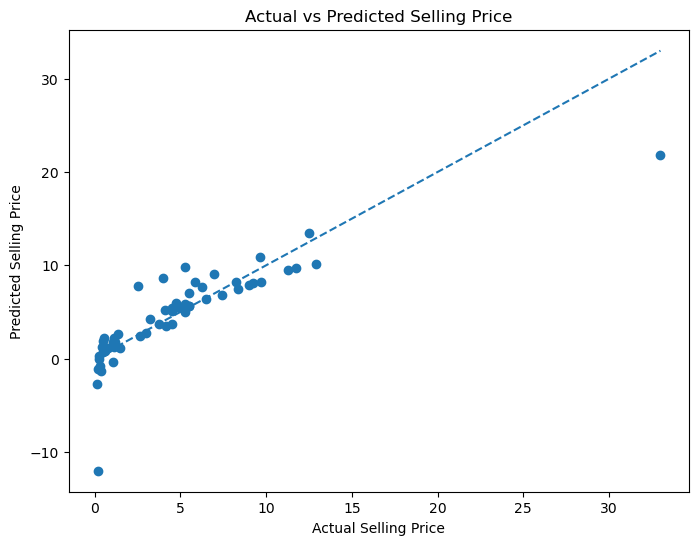

In [110]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

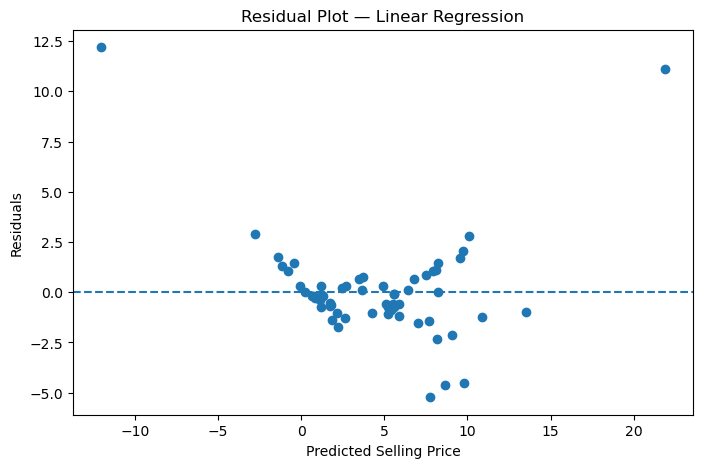

In [111]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 5))

plt.scatter(y_pred_lr, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.title("Residual Plot — Linear Regression")

plt.show()

In [112]:
import joblib

joblib.dump(preprocessor, "car_price_preprocessor.pkl")

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [113]:
joblib.dump(lr_model, "car_price_linear_regression.pkl")

print("Final model saved successfully.")

Final model saved successfully.


import os

print("Preprocessor exists:", os.path.exists("car_price_preprocessor.pkl"))
print("Model exists:", os.path.exists("car_price_linear_regression.pkl"))

In [115]:
loaded_preprocessor = joblib.load("car_price_preprocessor.pkl")
loaded_model = joblib.load("car_price_linear_regression.pkl")

X_test_loaded = loaded_preprocessor.transform(X_test)

test_predictions = loaded_model.predict(X_test_loaded)

print("Model loaded and prediction successful.")
print(test_predictions[:5])

Model loaded and prediction successful.
[7.93234144 7.49903628 1.18745335 6.80954897 9.79035013]


# Final Findings and Conclusion

## Final Model Performance

Three machine learning regression models were evaluated for predicting used car selling prices: Linear Regression, Decision Tree Regression, and Random Forest Regression.

| Model             |       MAE |  RMSE |        R² |
| ----------------- | --------: | ----: | --------: |
| Linear Regression |     1.463 | 2.626 | **0.733** |
| Decision Tree     | **1.442** | 3.110 |     0.625 |
| Random Forest     |     1.466 | 3.588 |     0.501 |

Based on the overall performance, **Linear Regression was selected as the final model**. It achieved the highest R² score of **0.733** and the lowest RMSE of **2.626** among the models tested.

## Key Findings

* **Present Price** showed the strongest numerical relationship with Selling Price, with a correlation of **0.876**.
* **Car Age** showed a negative correlation of **−0.234**, indicating that older vehicles generally tend to have lower selling prices.
* **Driven Kms** showed a very weak direct linear relationship with Selling Price, with a correlation of **0.029**.
* Feature engineering introduced **Car_Age** and **Kms_Per_Year** to provide additional information about vehicle age and usage.
* Outlier analysis identified unusual observations in Selling Price, Present Price, and Driven Kms. These were inspected and retained because they appeared to represent genuine vehicle observations rather than obvious data-entry errors.
* Vehicle model/name also had a noticeable influence on the predictions.
* The final model was trained using the preprocessed dataset with categorical variables encoded using One-Hot Encoding.

## Conclusion

This project demonstrates the use of data preprocessing, exploratory data analysis, feature engineering, and machine learning regression techniques to predict used car selling prices.

Among the evaluated models, **Linear Regression provided the best overall performance**, explaining approximately **73.25% of the variation in selling prices** on the held-out test set.

The results indicate that factors such as present market price, vehicle age, and vehicle model are important when estimating the resale value of used cars.

## Future Improvements

The model could potentially be improved by using a larger and more recent dataset, additional vehicle-related features, hyperparameter tuning, cross-validation, and more advanced regression algorithms.
